<a href="https://colab.research.google.com/github/Amri1003/Deep_Learning_Projects/blob/main/Pneumonia_Test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow

import keras

from skimage import io

import random

import numpy as np

import matplotlib.pyplot as plt

from numpy import expand_dims

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
# mount google drive

from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Remount Google Drive to ensure connection
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# load the dataset
import zipfile
zip_ref = zipfile.ZipFile("/content/drive/MyDrive/Pneumonia/archive (1).zip", 'r')
zip_ref.extractall("/content")
zip_ref.close()

In [ ]:
# load the dataset

import zipfile

zip_ref = zipfile.ZipFile("/content/drive/MyDrive/Pneumonia/archive (1).zip", 'r')

zip_ref.extractall("/content")

zip_ref.close()

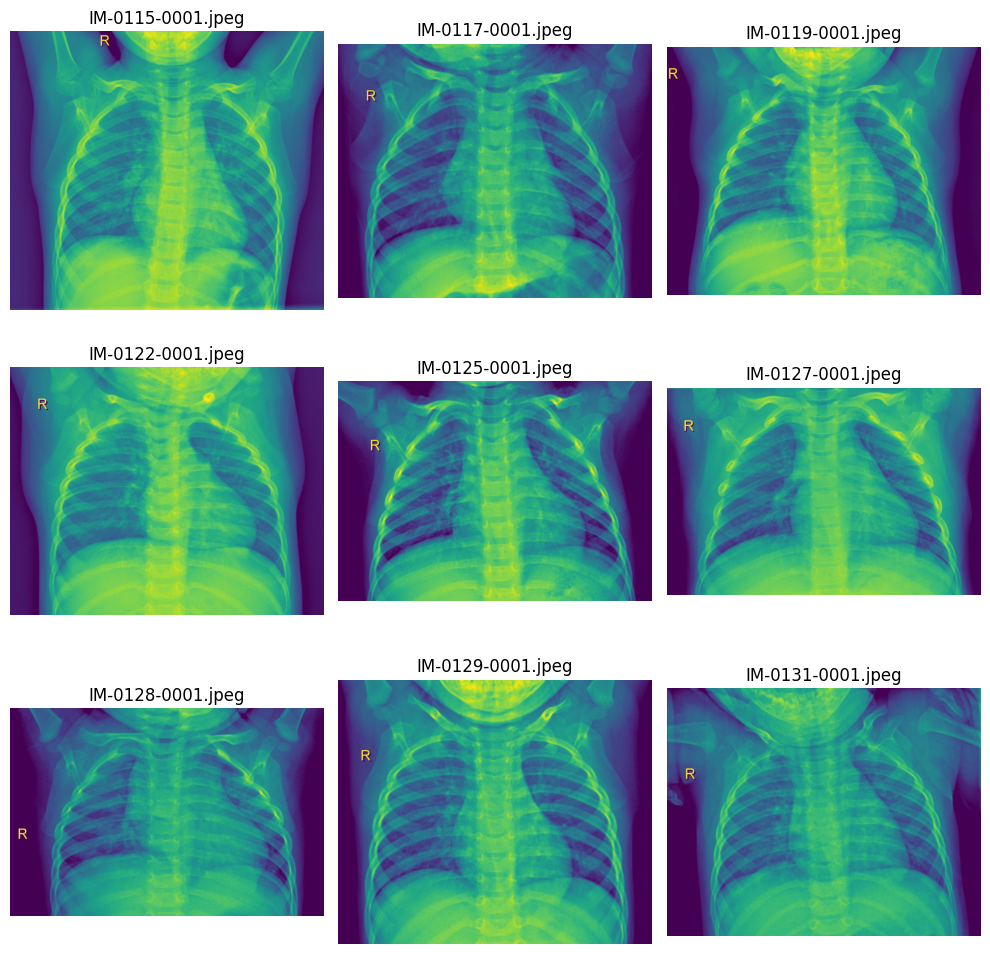

In [ ]:
# print some images from train data

import matplotlib.pyplot as plt
from matplotlib.image import imread
import os

Folder = '/content/chest_xray/train/NORMAL'

# Get a list of all files in the directory
all_files = os.listdir(Folder)

# Filter for image files (assuming .jpeg extension)
image_files = [f for f in all_files if f.endswith('.jpeg')]

# Sort the files to ensure consistent display, and take the first 9
image_files.sort()
files_to_display = image_files[:9]

plt.figure(figsize=(10, 10))
for i, filename in enumerate(files_to_display):

  plt.subplot(3, 3, i + 1)

  # Construct the full path using the actual filename
  full_path = os.path.join(Folder, filename)

  # Load the image using the full path
  image = imread(full_path)

  plt.imshow(image)

  plt.axis('off')
  plt.title(filename)

plt.tight_layout()
plt.show()

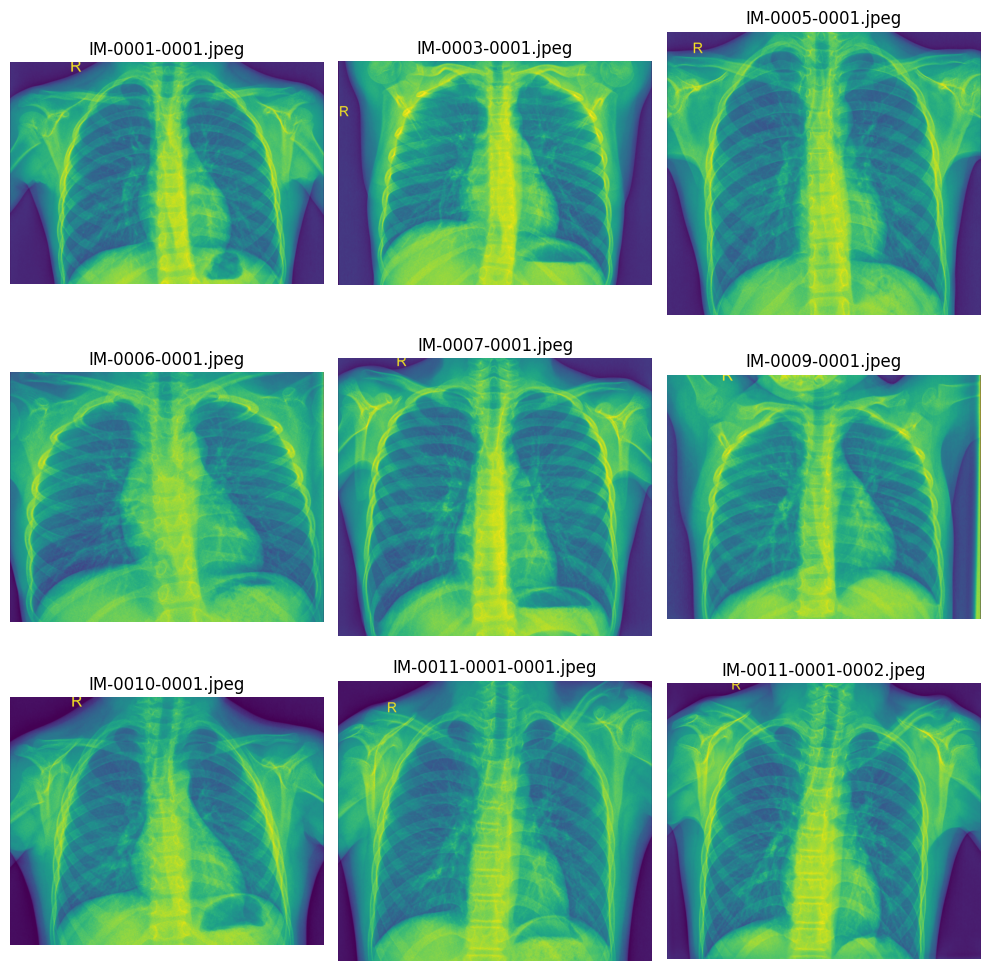

In [ ]:
# print some images from test data

import matplotlib.pyplot as plt
from matplotlib.image import imread
import os

Folder = '/content/chest_xray/test/NORMAL'

# Get a list of all files in the directory
all_files = os.listdir(Folder)

# Filter for image files (assuming .jpeg extension)
image_files = [f for f in all_files if f.endswith('.jpeg')]

# Sort the files to ensure consistent display, and take the first 9
image_files.sort()
files_to_display = image_files[:9]

plt.figure(figsize=(10, 10))
for i, filename in enumerate(files_to_display):

  plt.subplot(3, 3, i + 1)

  # Construct the full path using the actual filename
  full_path = os.path.join(Folder, filename)

  # Load the image using the full path
  image = imread(full_path)

  plt.imshow(image)

  plt.axis('off')
  plt.title(filename)

plt.tight_layout()
plt.show()

In [ ]:
# generate more images by applying some transformation on images

from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen=ImageDataGenerator(

    rescale=1./255,

    shear_range=0.2,

    zoom_range=0.2,

    horizontal_flip=True

)

Create test set and train set

In [ ]:
test_datagen=ImageDataGenerator(

    rescale=1./255

)

In [ ]:
training_set=train_datagen.flow_from_directory(

    '/content/chest_xray/train',

    target_size=(64,64),

    batch_size=32,

    class_mode='binary'

)

Found 5216 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_datagen=ImageDataGenerator(
    rescale=1./255
)

test_set=test_datagen.flow_from_directory(
    '/content/chest_xray/test',
    target_size=(64,64),
    batch_size=32,
    class_mode='binary'
)

Found 624 images belonging to 2 classes.


In [ ]:
# print the name of classes

training_set.class_indices

{'NORMAL': 0, 'PNEUMONIA': 1}

In [ ]:
# import library

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout

print('Library imported')

Library imported


In [ ]:
model=Sequential()

# add first conv layer

model.add(Conv2D(64,(3,3),activation='relu',input_shape=(64,64,3)))

model.add(MaxPooling2D(2,2))

model.add(Dropout(0.2))

# second conv layer

model.add(Conv2D(128,(3,3),activation='relu'))

model.add(MaxPooling2D(2,2))

model.add(Dropout(0.2))

# third conv layer

model.add(Conv2D(32,(3,3),activation='relu'))

model.add(MaxPooling2D(2,2))

model.add(Dropout(0.2))

# FCN

model.add(Flatten())

model.add(Dense(128,activation='relu'))

model.add(Dense(1,activation='sigmoid'))

model.summary()






/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 31, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 32)     │        36,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 260,257 (1016.63 KB)

 Trainable params: 260,257 (1016.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# compile the model

model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

print('model compiled')






model compiled


In [ ]:
# run the model

history=model.fit(training_set,epochs=5,validation_data=test_set)






Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 151s 913ms/step - accuracy: 0.7998 - loss: 0.4546 - val_accuracy: 0.8446 - val_loss: 0.3670
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 147s 903ms/step - accuracy: 0.8727 - loss: 0.2968 - val_accuracy: 0.8381 - val_loss: 0.3637
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 145s 890ms/step - accuracy: 0.8946 - loss: 0.2623 - val_accuracy: 0.8462 - val_loss: 0.3542
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 146s 894ms/step - accuracy: 0.9041 - loss: 0.2334 - val_accuracy: 0.8718 - val_loss: 0.3250
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 150s 916ms/step - accuracy: 0.9176 - loss: 0.2009 - val_accuracy: 0.8878 - val_loss: 0.2860


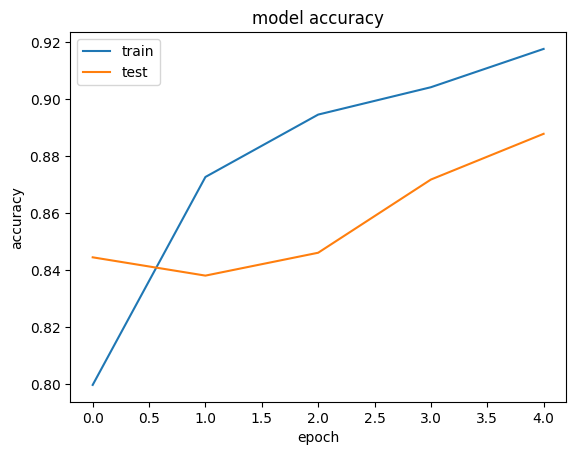

In [ ]:
# plot the accuracy and loss chart

import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title('model accuracy')

plt.ylabel('accuracy')

plt.xlabel('epoch')
plt.legend(['train','test'],loc='upper left')
plt.show()

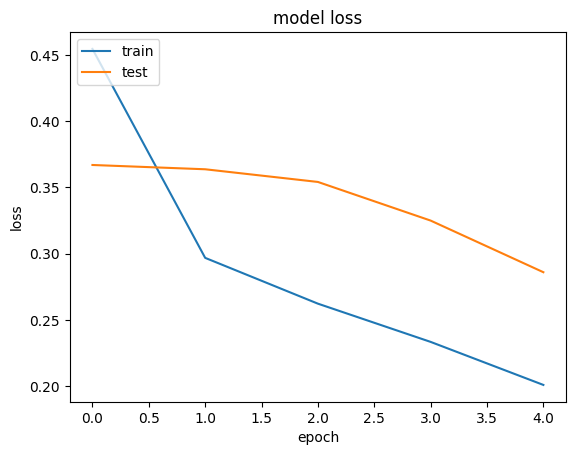

In [ ]:
# plot losses
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='upper left')
plt.show()

## Evaluate and Predict

In [ ]:
score=model.evaluate(test_set)
print('Test loss:',score[0])
print('Test accuracy:',score[1])

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 331ms/step - accuracy: 0.8878 - loss: 0.2860
Test loss: 0.28601598739624023
Test accuracy: 0.8878205418586731


In [ ]:
#train accuracy
score=model.evaluate(training_set)
print('Train loss:',score[0])
print('Train accuracy:',score[1])

163/163 ━━━━━━━━━━━━━━━━━━━━ 83s 511ms/step - accuracy: 0.9187 - loss: 0.1995
Train loss: 0.19946281611919403
Train accuracy: 0.9187116622924805


## Predict

In [ ]:
y_pred=model.predict(test_set)
y_pred.shape

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 336ms/step


(624, 1)

In [ ]:
y_pred[0]

array([0.08045798], dtype=float32)

In [ ]:
# save the model
model.save('Pneumonia.keras')
print('model saved')

model saved


In [ ]:
# load the model
from tensorflow.keras.models import load_model
loaded_model=load_model('Pneumonia.keras')
print('model loaded successfully')

model loaded successfully


In [ ]:
print(loaded_model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 31, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 32)     │        36,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 780,773 (2.98 MB)

 Trainable params: 260,257 (1016.63 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 520,516 (1.99 MB)

None


## Prediction on real data

In [ ]:
import numpy as np
from PIL import Image
new_image = Image.open('/content/No_Neumonia.jpg')


In [ ]:
new_image = new_image.resize((64, 64)).convert('RGB')

In [ ]:
# Convert the image to a numpy array and normalize
new_image_array = np.asarray(new_image)
new_image_array = new_image_array / 255.0  # Normalize to [0, 1]

# Expand dimensions to match the model input shape (batch_size, height, width, channels)
new_image_array = np.expand_dims(new_image_array, axis=0)

print('Image preprocessed for prediction.')

Image preprocessed for prediction.


In [ ]:
# Make a prediction
prediction = loaded_model.predict(new_image_array)

# Interpret the prediction
if prediction[0][0] > 0.5:
    print(f"Prediction: PNEUMONIA (Probability: {prediction[0][0]:.2f})")
else:
    print(f"Prediction: NORMAL (Probability: {prediction[0][0]:.2f})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Prediction: NORMAL (Probability: 0.05)
